In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256,  # Context length, Erlier we set it to 1024, here we've set it to 256 for training simplicity
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We reduce the context length (context_length) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens</li>
        <li>This is so that more readers will be able to follow and execute the code examples on their laptop computer</li>
    </ul>
</div>

In [2]:
import torch
import torch.nn as nn
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.w_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.w_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.w_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.w_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.w_query(x)
        values = self.w_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

In [4]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [5]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [6]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]), #Expansion
            GELU(), #Activation
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"]) #Contraction
        )
    
    def forward(self, x):
        return self.layers(x)

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
    
    def forward(self, x):
        #Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x) #Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # Add the original input back

        return x

In [8]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [9]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():# Disable gradient tracking for efficiency because we are not training, yet
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

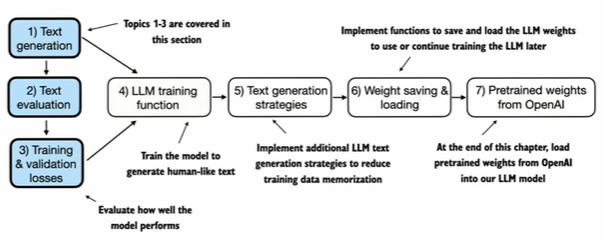

<h1>EVALUATING GENERATIVE TEXT MODELS</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    In this section we'll look into 1st and 2nd part of image shown above, which are Text generation and Text evaluation.
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    How to measure LLM prediction loss?
    <ul>
        <li>How do we vaidate that generated text is of good quality or not by any quantitative metric?</li>
        <li>That quantitative metric is <b>Loss function</b>.</li>
        <li>If we can define a Loss function which quantifies how good or bad our LLM performance is, we can minimize the loss so that LLM can perform better.</li>
        <li>To get the loss function we need Inputs (Predicted values) and Target (True values).</li>
        <li>Loss function will be determined by Input and Targert values and how close they are.</li>
    </ul>
</div>

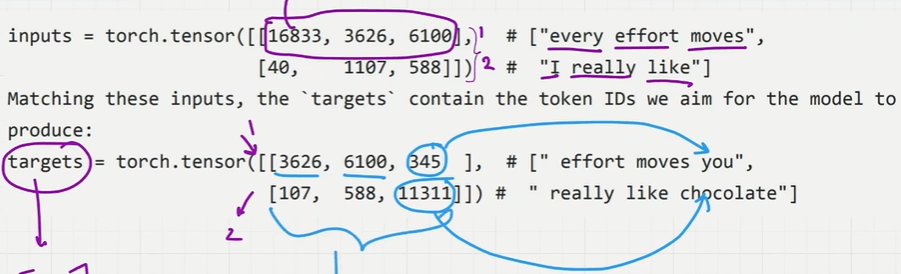

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As shown in image above, In inputs tensor we've 2 batches each containing 3 tokens. </li>
        <li>In targets tensor, we've 2 batches each containing 3 tokens. Here in each batch, 3rd token is correct generated word for inputs</li>
        <li>i.e. For inputs ["every", "effort", "moves"], target is ["effort", "moves", "you"]. Here "you" should be correct generated word</li>
        <li>Targets tneso contains true values to be predicted.</li>
        <li>Here 3 prdictions are generated, based on max_new_token which defines howmany maximum tokens can be generated for a batch.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Below is the illustration for LLM text generation
</div>

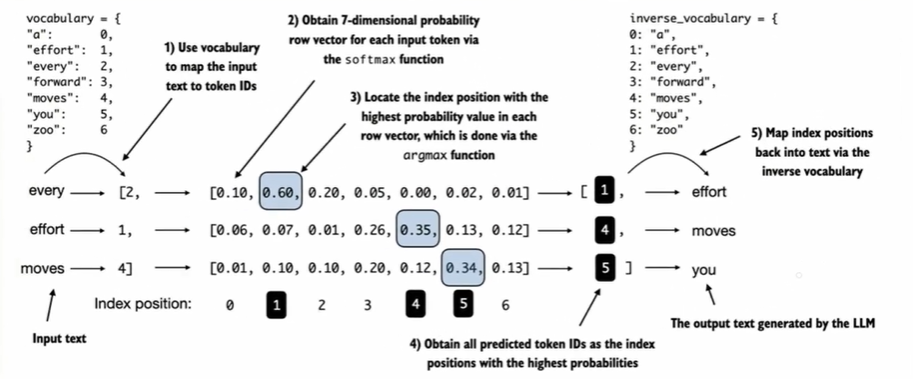

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    We want output tokenIds should be as close to the target toenIds. So to calculating LLM loss we'll compare output tokenIds with target tokenIds.
</div>

In [10]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Next, we use the generate_text_simple function from the previous chapter to generate text.</li>
        <li>In addition, we define two convenience functions, text_to_token_ids and token_ids_to_text, for converting between token and text representations that we use throughout this chapter</li>
    </ul>
</div>

In [11]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see above, the model does not produce good text because it has not been trained yet.</li>
        <li>How do we measure or capture what "good text" is, in a numeric form, to track it during training?</li>
        <li>The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress</li>
        <li>The next chapters on finetuning LLMs will also introduce additional ways to measure model quality</li>
    </ul>
</div>

<h3>Calculating the text generation loss: cross-entropy and perplexity</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Suppose we have an inputs tensor containing the token IDs for 2 training examples (rows)</li>
        <li>Corresponding to the inputs, the targets contain the desired token IDs that we want the model to generate</li>
        <li>Notice that the targets are the inputs shifted by 1 position, as explained in chapter 2 when we implemented the data loader</li>
    </ul>
</div>

In [12]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Feeding the inputs to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each</li>
        <li>Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary</li>
        <li>Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores</li>
    </ul>
</div>

In [13]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As discussed in the previous chapter, we can apply the argmax function to convert the probability scores into predicted token IDs.</li>
        <li>The softmax function above produced a 50,257-dimensional vector for each token; the argmax function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token.</li>
        <li>Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:</li>
    </ul>
</div>

In [14]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens.</li>
        <li>We want these output tokenIds to be as close as possible to target tokenIds.</li>
        <li>That's because the model wasn't trained yet.</li>
        <li>To train the model, we need to know how far it is away from the correct predictions (targets).</li>
    </ul>
</div>

In [15]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


<h3>Cross-entropy loss</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We have target tensor and probability logits.</li>
        <li>From target tensors, for each batch we get target tokenIds. By using these tokenIds we fetch prababilities for each tokenId from logits tensor.</li>
        <li>It may happen that these probabilities are not highest among all logits for that tokenId.</li>
        <li>Goal of training is to get these probability values as close to 1 as possible.</li>
        <li>If these probability values are close to 1 as possible then when LLM fetches tokenIds with highest probabilities, we get target tokenIds. Which ensures accurate output of LLM.</li>
    </ul>
</div>

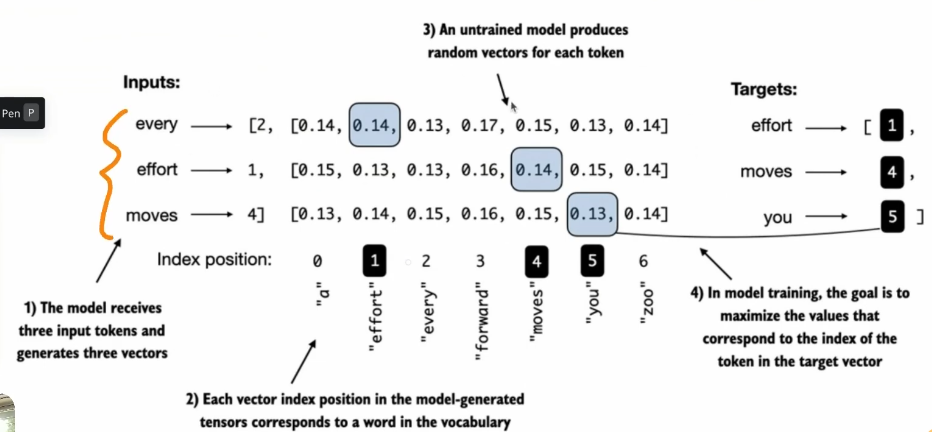

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Store target probabilities for all batch in single array</li>
        <li>Take logarithm of all these values.</li>
        <li>Then take average of all logarithm values.</li>
        <li>Take negative of this average.</li>
        <li>This final value is <b>Cross entropy loss</b>. We want this loss to be as minimimum as possible and as close to 0 as possible.</li>
    </ul>
</div>

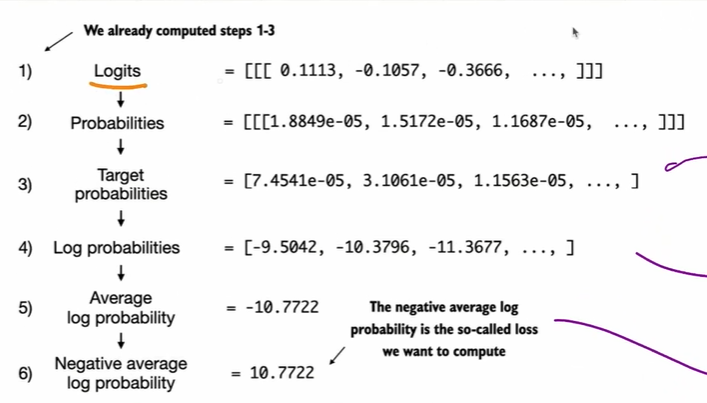

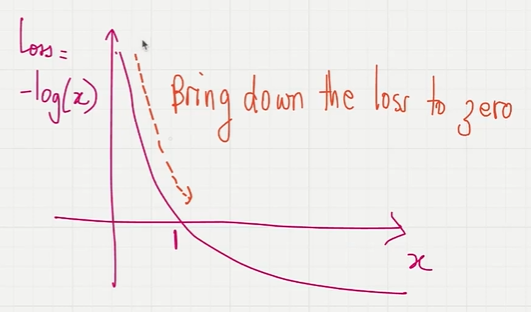

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Dimensions of logits tensor is (no. of batches)*(no. of tokens)*(vocab_size). for eaxample, 2*3*50257.</li>
        <li>Flatten the logits tensor, (no. all tokens of all batches)*(vocab_size). for example, 6*50257.</li>
    </ul>
</div>

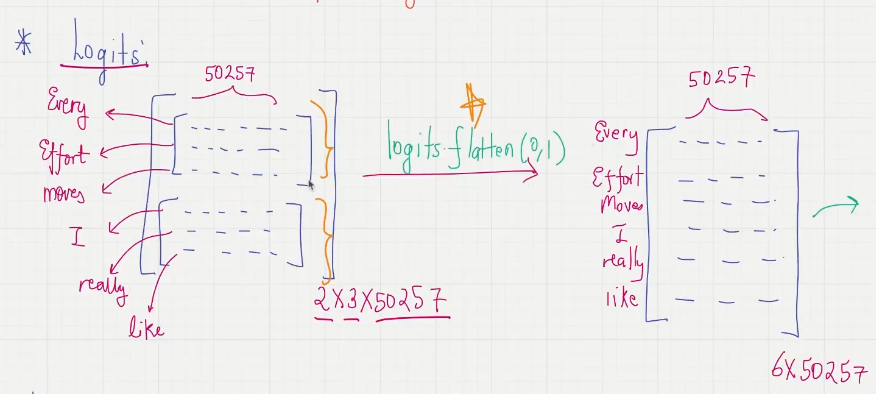

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Dimension of target tensor is (no. of batches)*(no. of tokens). for example, 2*3.</li>
        <li>Flatten the target tensor merge all tokenIds in a tensor. For example, 1*6.</li>
    </ul>
</div>

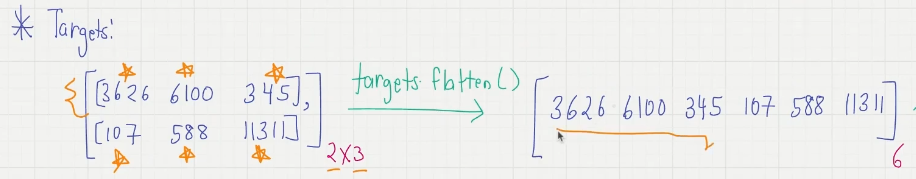

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    The steps described for cross entropy function can be done in single step.
</div>

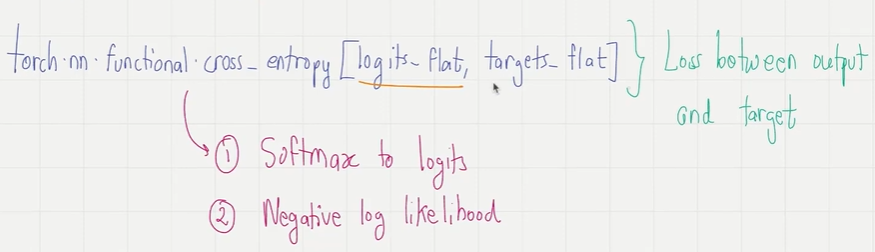

<div style="background-color: #21CC77; color: black; padding: 10px;">
    The token probabilities corresponding to the target indices are as follows:
</div>

In [16]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]] #get probabilities for 1st batch for target tensor tokenIds
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]] #get probabilities for 2nd batch for target tensor tokenIds
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We want to maximize all these values, bringing them close to a probability of 1.</li>
        <li>In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself.</li>
    </ul>
</div>

In [17]:
concat_target_probas = torch.cat((target_probas_1, target_probas_2))
print(concat_target_probas)
log_probas = torch.log(concat_target_probas)
print(log_probas)

tensor([7.4540e-05, 3.1061e-05, 1.1563e-05, 1.0337e-05, 5.6776e-05, 4.7559e-06])
tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Next, we compute the average log probability:
</div>

In [18]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The goal is to make this average log probability as large as possible by optimizing the model weights.</li>
        <li>Due to the log, the largest possible value is 0, and we are currently far away from 0.</li>
        <li>In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0.</li>
        <li>The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning.</li>
    </ul>
</div>

In [19]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>PyTorch already implements a cross_entropy function that carries out the previous steps</li>
        <li>Before we apply the cross_entropy function, let's check the shape of the logits and targets</li>
    </ul>
</div>

In [20]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    For the cross_entropy function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:
</div>

In [21]:
logits_flat = logits.flatten(0, 1) 
# (0,1) as parameters means that 0th dimension ans 1st dimension is multiplied to calulate new 0th dimensions and merge the batches.
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize.</li>
        <li>The cross_entropy function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized</li>
    </ul>
</div>

In [22]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


<h3>Perplexity : Another measure like cross entropy</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Measure how well the probability distribution predicted by the model matches that actual distribution of words in the dataset.</li>
        <li>More interpretable way of understanding model uncertainty in predicting next token.</li>
        <li>Lower perplexity score = Better prediction</li>
        <li>For example we took, <b>perplexity = torch.exp(loss)</b> = 48725. Model is roughly as uncertain as if it had to choose the next token randomly from about 48725 tokens in the vocabulary. This number is much more interpretable.</li>
    </ul>
</div>

In [23]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens).</li>
        <li>In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset.</li>
        <li>Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Loss function in LLM pretraining:</b><br>
    <ul>
        <li>The quantitative metric to measure if LLM generated text is good or bad is <b>Loss function</b>.</li>
        <li>To calculate LLM loss, first we use target tokenId tensor to extract probabilities for these tokenIds from logits > Merge all probailities in a tensor > Take logarithm of it > Take average of these logarithmic values > Find negative of it.</li>
        <li>We can find LLM loss value by torch.nn.functional.cross_entropy(logits_flat, targets_flat). This method accepts flattned logits and flattened target tokeId tensor.</li> 
        <li>Exponential value of LLM loss gives <b>Perplexity</b>. The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens).</li>
    </ul>
</div>

<h1>Evaluating LLM performance on real dataset</h1>

<h3>Calculating the training and validation set losses</h>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The dataset we're using is "The Verdict" book which contains ~20000 characters and ~5000 tokens.</li>
        <li>In training process we'll use train_ratio=0.9 which means that training data is 90% of initial part of dataset and later 10% is used for validation of generated text.</li>
        <li>Use dataloader to chunk training and validation data into input and output datasets.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In input target pairs, no of input tokenIds is set by context_size and for target output for it is selected by input shifted by one token. i.e. if input is "I had always thought" the target output for it is "had always thought tack".</li>
        <li>The number of token shift to select next input sequence is decided by stride. i.e. if 1st input sequence is "I had always thought" (context_size is 4) and if stride is 3 then next input sequence will be "thought Jack Gibson rather". </li>
        <li>Here stride is less then context size then there will be overlapping between two input sequences. If stride is greater than or eual to context length then there will be no overlapping.</li>
        <li>The input is passed to LLM model which we'll give use the output. Loss is calculated between target for that input and output generated by LLM.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Here's the illustration of train dataset and validation dataset which contains input target pairs.
</div>

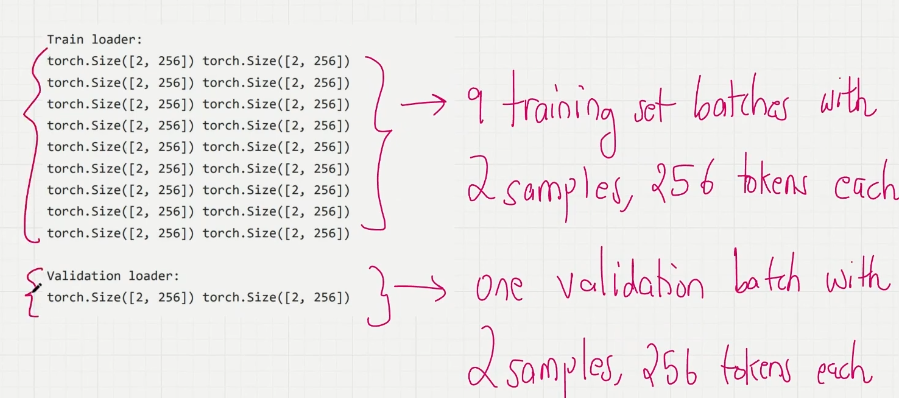

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We use a relatively small dataset for training the LLM (in fact, only one short story)</li>
        <li>The reasons are:
            <ul>
                <li>You can run the code examples in a few minutes on a laptop computer without a suitable GPU.</li>
                <li>The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes.</li>
                <li>We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size.</li>
                <li>For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens</li>
                <li>At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately 30 dollars.</li>
                <li>So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * 30 = 690,000 dollars</li>
                <li>Below, we use the same dataset we used in data pre processing.</li>
            </ul>
        </li>
    </ul>
</div>

In [24]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [25]:
# A quick check that the text loaded ok by printing the first and last 100 words
# First 100 characters
print(text_data[:99])
# Last 100 characters
print(text_data[-99:])

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 
it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."
Characters: 20479
Tokens: 5145


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later).</li>
        <li>Next, we divide the dataset into a training and a validation set and use the data loaders from chapter data pre processing to prepare the batches for LLM training.</li>
        <li>Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position</li>
    </ul>
</div>

<h3>Implementing the DataLoader:</h3>

In [26]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [27]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [28]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with.</li>
        <li>Llama 2 7B was trained with a batch size of 1024, for example.</li>
    </ul>
</div>

In [29]:
# An optional check that the data was loaded correctly:

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

print(len(train_loader))
print(len(val_loader))

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
9
1


In [30]:
# An optional check that the data was loaded correctly:

train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Next, we implement a utility function to calculate the cross-entropy loss of a given batch.</li>
        <li>In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader.</li>
    </ul>
</div>

In [31]:
def calc_loss_batch(input_batch, target_batch, model, device):
    # Flatten input and target batch and calculate cross entropy loss for a batch
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        #aggregate loass for all batches in data loader
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    
    #return mean loss of the dataloader
    return total_loss / num_batches

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code.</li>
        <li>Via the device setting, we ensure that the data is loaded onto the same device as the LLM model.</li>
    </ul>
</div>

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#
# print(f"Using {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad():# Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758347829183
Validation loss: 10.98110580444336


<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Evaluating LLM performance on real dataset:</b><br>
    <ul>
        <li>The purpose of this section is to find loss function values for a real dataset which is "The Verdict" book.</li>
        <li>Here first we devide whole dataset into two dataset, one for tarin dataset and one for validation dataset.</li>
        <li>Here 90% of dataset is used for train dataset and 10% dataset is used for validation dataset.</li> 
        <li>Then we define two data loaders, one for train dataset and one for validationd dataset.</li>
        <li>Here in this example, train dataloader contains 9 batches (each batch contains input and target tokenId pairs) and validation data loader contains 1 batch ((each batch contains input and target tokenId pairs)).</li>
        <li>Here we've implemented <b>calc_loss_loader</b> which returns loss function values for a dataloader whether it's tarining dataloader or validation dataloader.</li>
    </ul>
</div>

<h1>TRAINING LOOP FOR THE LLM</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In this section we'll implement LLM pre-training function.</li>
        <li>We'll use back propogation strategy to train the LLM</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    LLM pretraining loop schematic:
</div>

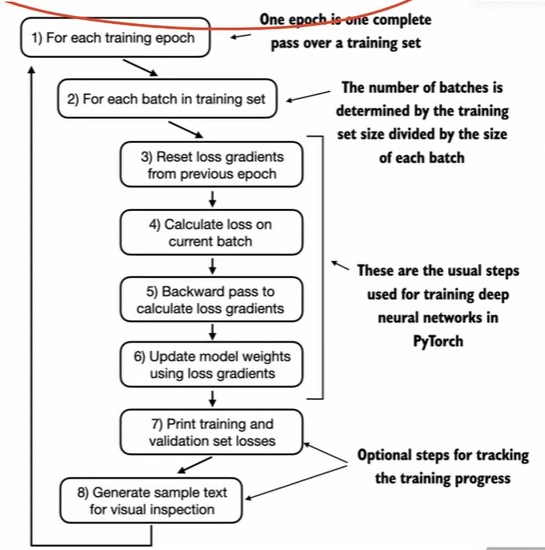

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>There will be multiple epochs while training epoch. <b>One epoch is one complete pass over a training dataset once.</b> If training epoch is 10 then we repeat training process for whole dataset 10 times.</li>
        <li>In each epoch we'll have multiple batches. We'll look into one batch in one loop.</li>
        <li>For each loop:
            <ul>
                <li>First we'll reset loss gradients we calculated in pervious iteration.</li>
                <li>Then we'll find the cross entropy loss function for entire batch.</li>
                <li>Then we'll do back propogation to calculate loss gradient for that iteration.</li>
                <li>Then update model weights using loss gradients with respect to all 162 million parameters. w=w−α⋅(∂J(w)/∂w)</li>
                <li>Update model weights using loss gradient.</li>
                <li>Print training and validation set losses</li>
            </ul>
        </li>
        <li>This steps will be repeated for each batch</li>
        <li>Main step : Find loss gradients using loss.backward() method of pytorch.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Number of parameters for LLM are no. of trainable weights which are subjected for training for this LLM which can be calculated as below :</li>
        <li>No. embedding parameters = Embedding layer + Positional layer = (vocabulary_size*embedding dimensions) + (context_size*embdding dimensions) = 50257*768 + 1024*768 = <b>38.4 million</b></li>
        <li>No. Transformer block parameters = 12*(Multi head attention parameters + Feed forward neural network parametrs)
            <ul>
                <li>Multi head attention parameters = (3*embedding_dimensions*embedding_dimensions + embedding_dimensions*embedding_dimensions) =  (query, key, value weights + output head) = 3*768*768 + 768*768 = 1.77 million + 0.59 million = 2.36 million</li>
                <li>Feed forward neural network parameters = Expansion layer parameters + Contraction layer patameters = 768*(4*768)+768*(4*768) = 4.72 million</li>
            </ul>
            12*(2.36 + 4.72) ~ <b>85.2 millions</b>
        </li>
        <li>Final softmax layer parameters (logits tensor) = embedding_parameters*vocab_size =  768*50257 = <b>38.4 millions</b></li>
        <li>These all values add upto nearly <b>162 millions</b>.</li>
        <li>GPT2 model has 124 million parameters. This difference is due to weight tying. In output projection layer they recycle the same number of parameters in the embedding layer. Which reduces the number of parameters.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>In backward pass, gradient weights are updated by following formula for each iteration.</li>
        <li>When gradient weights are keeps getting updates, value of loss function will keep decreasing which means that difference between target value and generated output is decreasing which increases the quality and accuracy of output.</li>
    </ul>
</div>

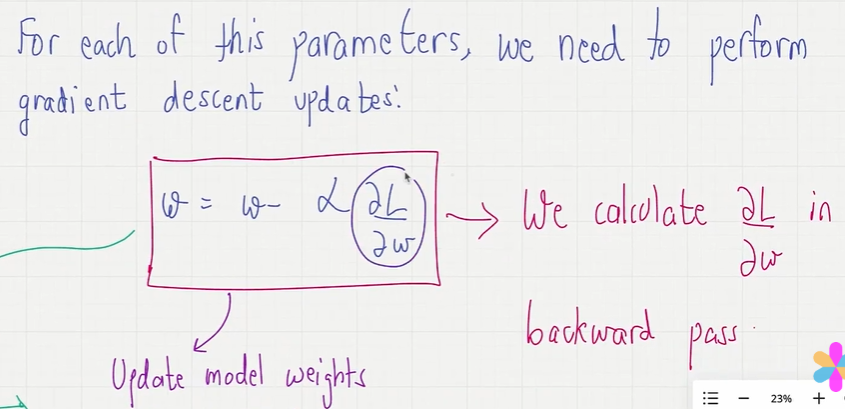

In [33]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            #We haven't defined optimizer yet, we'll define it shortly
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Step 1: Initialize lists to track losses and tokens seen</li>
        <li>Step 2: Start the main training loop</li>
        <li>Step 3: Reset loss gradients from previous batch iteration</li>
        <li>Step 4: Calculate loss gradients</li>
        <li>Step 5: Update model weights using loss gradients</li>
        <li>Step 6: Optional evaluation step</li>
        <li>Step 7: Print a sample text after each epoch</li>
    </ul>
</div>

In [34]:
#calculate training loss and validation loss
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() #model is in evaluation mode
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    The evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets
</div>

In [35]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.</li>
        <li>In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <ul>
        <li>Let's see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier.</li>
        <li><b>Additional note</b> : AdamW is an optimizer which uses weight decay. It is a go to choice for optimizer because it avoids local minima and leads to fater convergence.</li>
    </ul>
</div>

In [39]:
# Note:
# Uncomment the following code to calculate the execution time
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10 #repeat entire process 10 times
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.783, Val loss 9.927
Ep 1 (Step 000005): Train loss 7.985, Val loss 8.335
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.753, Val loss 7.048
Ep 2 (Step 000015): Train loss 6.114, Val loss 6.573
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,,,,, and,,,, and,, and,,,,, and,,,,,,
Ep 3 (Step 000020): Train loss 5.525, Val loss 6.490
Ep 3 (Step 000025): Train loss 5.324, Val loss 6.387
Every effort moves you, and to the picture.                      "I, and the of the of the's the honour, and, and I had been, and I
Ep 4 (Step 000030): Train loss 4.761, Val loss 6.360
Ep 4 (Step 000035): Train loss 4.461, Val loss 6.258
Every effort moves you of the to the picture--as of the picture--as I had been " it was his " I was the     "I was his I had been the his pictures--and it the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.833, Val loss 6.196
Every effort moves yo

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see, based on the results printed during the training, the training loss improves drastically, starting with a value of 9.78 and converging to 0.506.</li>
        <li>The language skills of the model have improved quite a lot. In the beginning, the model is only able to append commas to the start context ("Every effort moves you,,,,,,,,,,,,") or repeat the word "and".</li>
        <li>At the end of the training, it can generate grammatically correct text.</li>
        <li>Similar to the training set loss, we can see that the validation loss starts high (9.927) and decreases during the training.</li>
        <li>However, it never becomes as small as the training set loss and remains at 6.325 after the 10th epoch.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    Let's create a simple plot that shows the training and validation set losses side by side
</div>

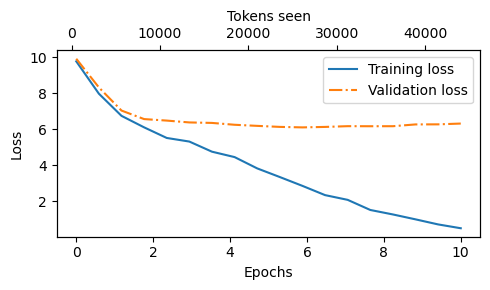

In [43]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch.</li>
        <li>This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.</li>
        <li>We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, such as "quite insensible to the irony" in the "The Verdict" text file.</li>
        <li>This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs.</li>
        <li>Usually, it's common to train a model on a much, much larger dataset for only one epoch.</li>
    </ul>
</div>

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Coding entire LLM Pre-tarining loop</b><br>
    <ul>
        <li>There will be multiple epochs while training epoch. <b>One epoch is one complete pass over a training dataset once.</b> If training epoch is 10 then we repeat training process for whole dataset 10 times.</li>
        <li>In each epoch we'll have multiple batches. We'll look into one batch in one loop.</li>
        <li>For each loop:
            <ul>
                <li>First we'll reset loss gradients we calculated in pervious iteration.</li>
                <li>Then we'll find the cross entropy loss function for entire batch.</li>
                <li>Then we'll do back propogation to calculate loss gradient for that iteration.</li>
                <li>Then update model weights using loss gradients with respect to all 162 million parameters. w=w−α⋅(∂J(w)/∂w)</li>
                <li>Update model weights using loss gradient.</li>
                <li>Print training and validation set losses</li>
            </ul>
        </li>
        <li>This steps will be repeated for each batch</li>
        <li>Main step : Find loss gradients using loss.backward() method of pytorch.</li>
    </ul>
</div>

<h1>DECODING STRATEGIES TO CONTROL RANDOMNESS</h1>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Until now, the generated token is selected corresponding to the largest probability score among all tokens in the vocabulary.</li>
        <li>Which leads to a lot of randomness and diversity in generated text.</li>
        <li>We will learn 2 techniques to control this randomness :
            <ul>
                <li><b>Temperature scaling</b></li>
                <li><b>Top-K sampling</b></li>
            </ul>
        </li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>First, we briefly revisit the generate_text_simple function from the previous chapter that we used inside the generate_and_print_sample earlier in this chapter.</li>
        <li>Then, we will cover two techniques, temperature scaling, and top-k sampling, to improve this function.</li>
        <li>We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU.</li>
        <li>Also, after training, we put the model into evaluation model to turn off random components such as dropout:</li>
    </ul>
</div>

In [36]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_key): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (w_query): Linear(in_features

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Next, we plug the GPTModel instance (model) into the generate_text_simple function, which uses the LLM to generate one token at a time:
</div>

In [37]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren Mortgage TT remember gard ACTIONSussedOND Land Engeleddedemate breaths proxies GalaxyForm


<h3>DECODING STRATEGY 1: TEMPERATURE SCALING</h3>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Replace argmax with probability distribution.</li>
        <li>Multinimial probability distribution samples next token according to probability score.</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>Previously, inside the generate_text_simple function, we always sampled the token with the highest probability as the next token using torch.argmax, also known as greedy decoding.</li>
        <li>To generate text with more variety, we can replace the argmax with a function that samples from a probability distribution (here, the probability scores the LLM generates for each vocabulary entry at each token generation step).</li>
        <li>To illustrate the probabilistic sampling with a concrete example, let's briefly discuss the next-token generation process using a very small vocabulary for illustration purposes:</li>
    </ul>
</div>

In [38]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Next, assume the LLM is given the start context "every effort moves you" and generates the following next-token logits:
</div>

In [ ]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

next_token_logits2 = next_token_logits/0.1

next_token_logits3 = next_token_logits/5

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    As discussed in the previous chapter, inside the generate_text_simple, we convert the logits into probabilities via the softmax function and obtain the token ID corresponding the generated token via the argmax function, which we can then map back into text via the inverse vocabulary:
</div>

In [62]:
probas = torch.softmax(next_token_logits2, dim=0)

print(probas)

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])


In [ ]:
probas = torch.softmax(next_token_logits3, dim=0)

print(probas)

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])


In [60]:
probas = torch.softmax(next_token_logits, dim=0)

print(probas)

next_token_id = torch.argmax(probas).item()

print(next_token_id)

print(inverse_vocab[next_token_id])

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
3
forward


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    To implement a probabilistic sampling process, we can now replace the argmax with the multinomial function in PyTorch:
</div>

In [ ]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
7
toward


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>The printed output is "forward" just like before. What happened? The multinomial function samples the next token proportional to its probability score.</li>
        <li>In other words, "forward" is still the most likely token and will be selected by multinomial most of the time but not all the time.</li>
        <li>To illustrate this, let's implement a function that repeats this sampling 1000 times:</li>
    </ul>
</div>

In [44]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>As we can see based on the output, the word "forward" is sampled most of the time (544 out of 1000 times), but other tokens such as "closer", "inches", and "toward" will also be sampled some of the time.</li>
        <li>This means that if we replaced the argmax function with the multinomial function inside the generate_and_print_sample function, the LLM would sometimes generate texts such as "every effort moves you toward", "every effort moves you inches", and "every effort moves you closer" instead of "every effort moves you forward".</li>
    </ul>
</div>

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>We can further control the distribution and selection process via a concept called temperature scaling, <b>where temperature scaling is just a fancy description for dividing the logits by a number greater than 0</b>.</li>
        <li>Temperatures greater than 1 result in more uniformly distributed token probabilities, and Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions.</li>
    </ul>
</div>

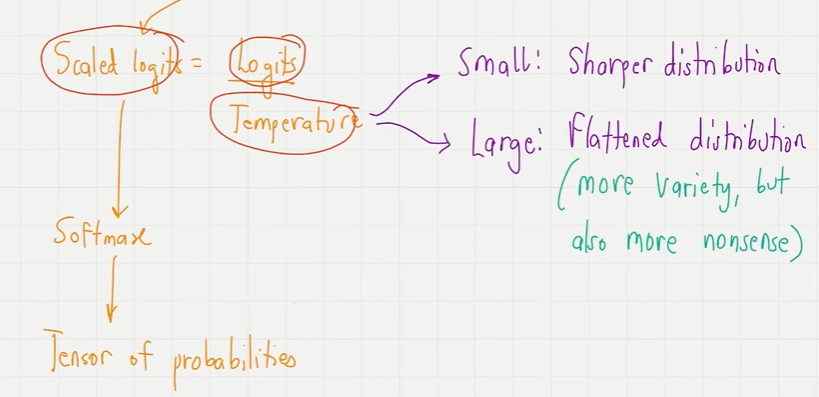

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    Let's illustrate this by plotting the original probabilities alongside probabilities scaled with different temperature values:
</div>

In [ ]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

##Multinomial distribution is applied after softmax of temperatire scaled probabilities

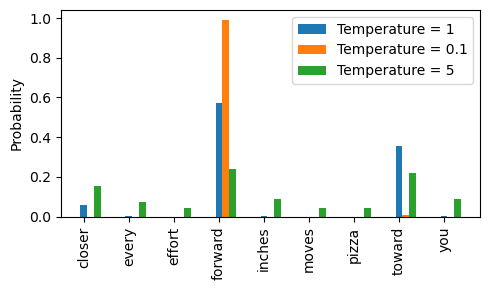

In [49]:
import matplotlib.pyplot as plt

# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

<div style="background-color: #B8B8FF; color: black; padding: 10px">
    <ul>
        <li>A temperature of 1 divides the logits by 1 before passing them to the softmax function to compute the probability scores.</li>
        <li>In other words, using a temperature of 1 is the same as not using any temperature scaling.</li>
        <li>In this case, the tokens are selected with a probability equal to the original softmax probability scores via the multinomial sampling function in PyTorch.</li>
        <li>Applying very small temperatures, such as 0.1, will result in sharper distributions such that the behavior of the multinomial function selects the most likely token (here: "forward") almost 100% of the time, approaching the behavior of the argmax function.</li>
        <li>Vice versa, a temperature of 5 results in a more uniform distribution where other tokens are selected more often.</li>
        <li>This can add more variety to the generated texts but also more often results in nonsensical text.</li>
        <li>For example, using the temperature of 5 results in texts such as "every effort moves you pizza" about 4% of the time.</li>
    </ul>
</div>

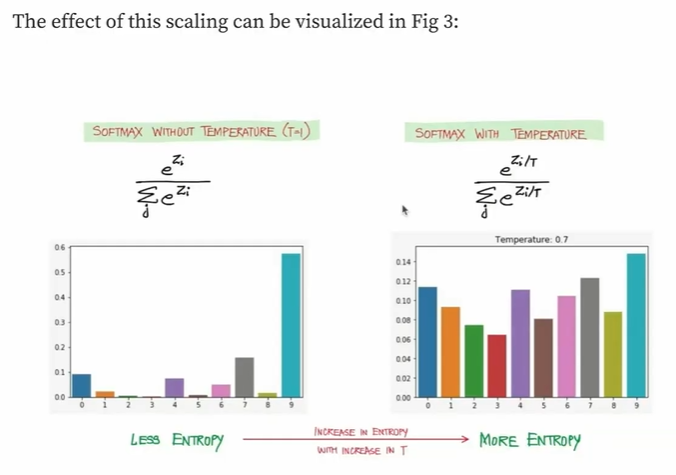

<div style="background-color: #21CC77; color: black; padding: 10px;">
    <b>Summary of Temperature scaling</b><br>
    <ul>
        <li>Until now, the generated token is selected corresponding to the largest probability score among all tokens in the vocabulary. Which leads to a lot of randomness and diversity in generated text. We use temperature scling to control this randomness.</li>
        <li>where temperature scaling is just a fancy description for dividing the logits by a number greater than 0</li>
        <li>Temperatures greater than 1 result in more uniformly distributed token probabilities, and Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions.</li>
        <li>First we divide logits with temperature (scaling logits with temperature). Then apply softmax to find probabilities.</li>
        <li>Then we use multinomial distribution to sample (probabilistic sampling process) next token rather than using argmax.</li>
        <li>As temperature becomes high > Entropy Increases > Every vocab token has probbility to become next token > randomness (creativity) of generated text increase > which sometime can be nonsense. </li>
        <li>As temperature is low > entropy is low > Concentration on single tokem > sharper probability distribution > accurate next token generation.</li>
    </ul>
</div>